正在执行两表合并...
 当前数据集共有176个主题。

正在生成7个可视化图表


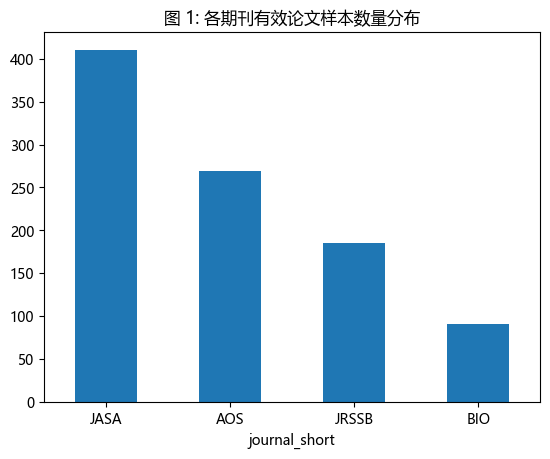

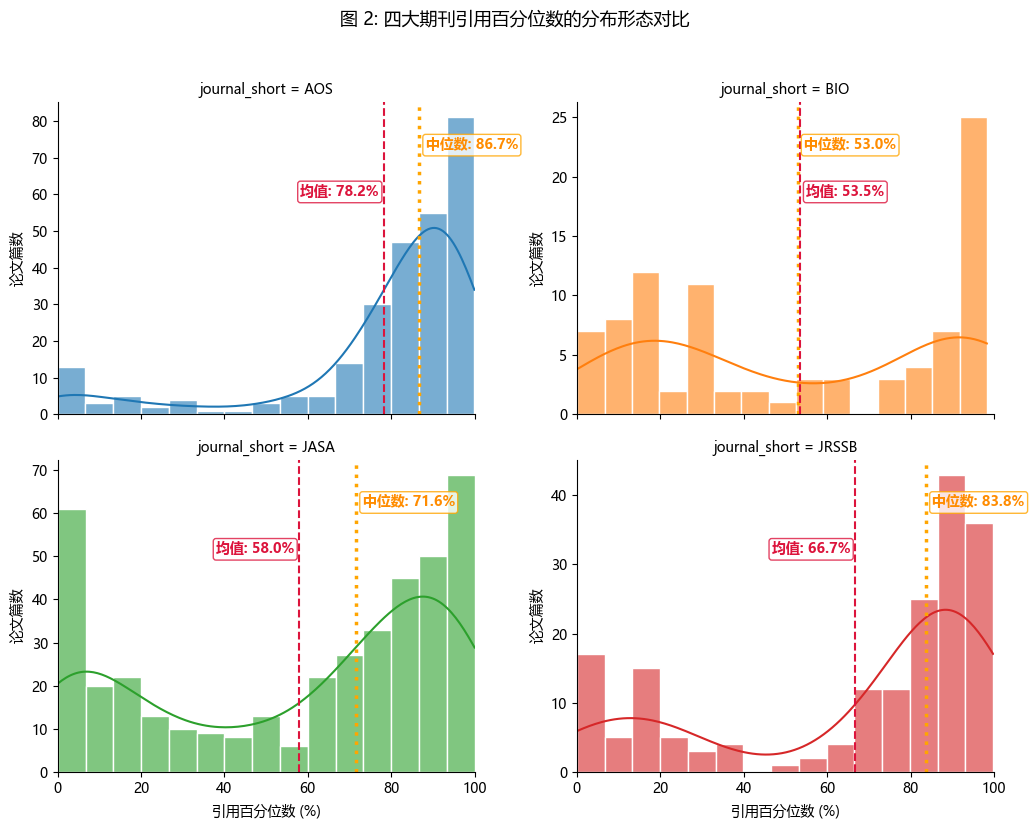

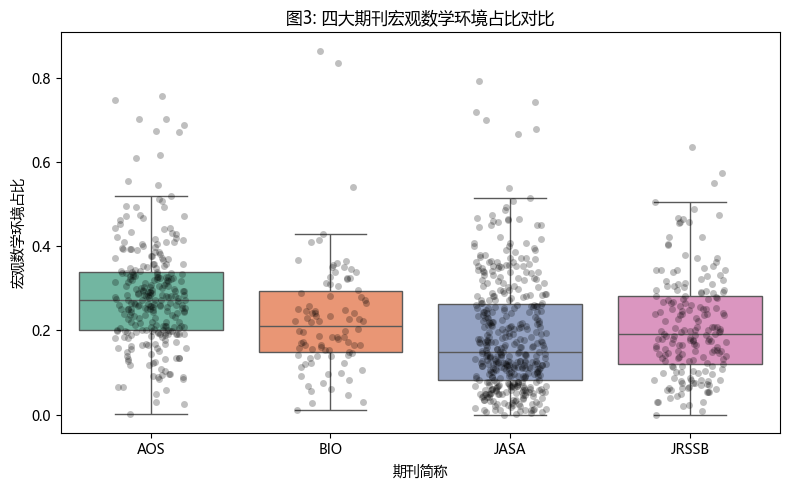

-> 正在绘制图 4-1...


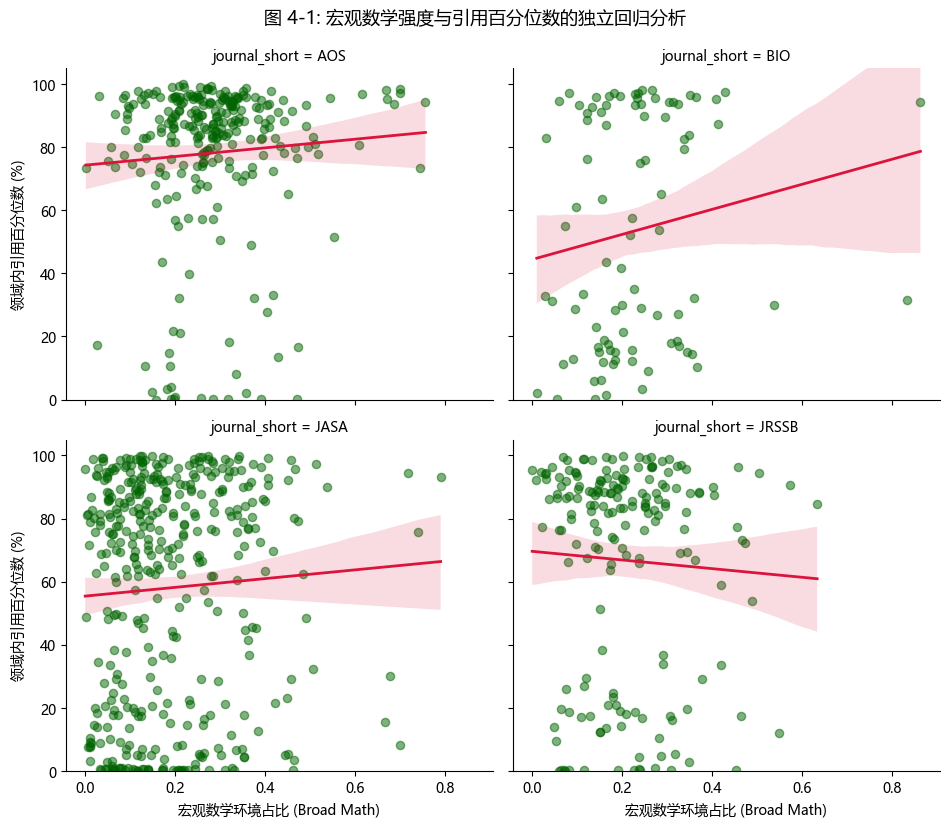

-> 正在绘制图 4-2...


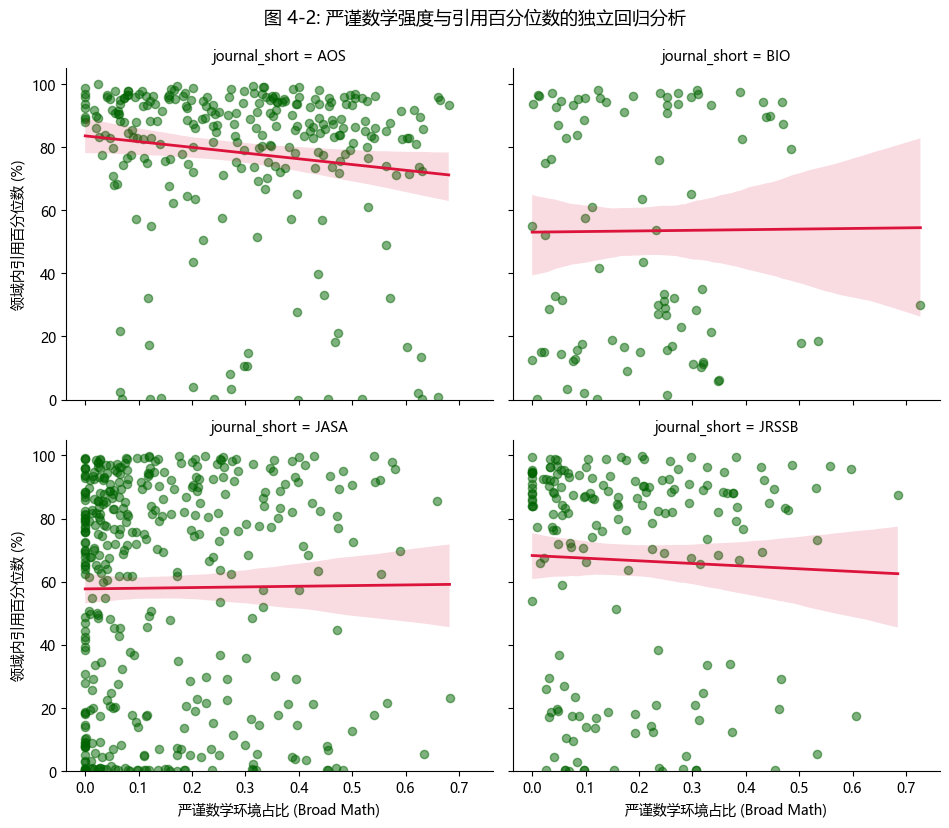

准备回归分析的分组数据 (按 50 引用百分位拆分)
-> 正在绘制图 4-1 (new)...


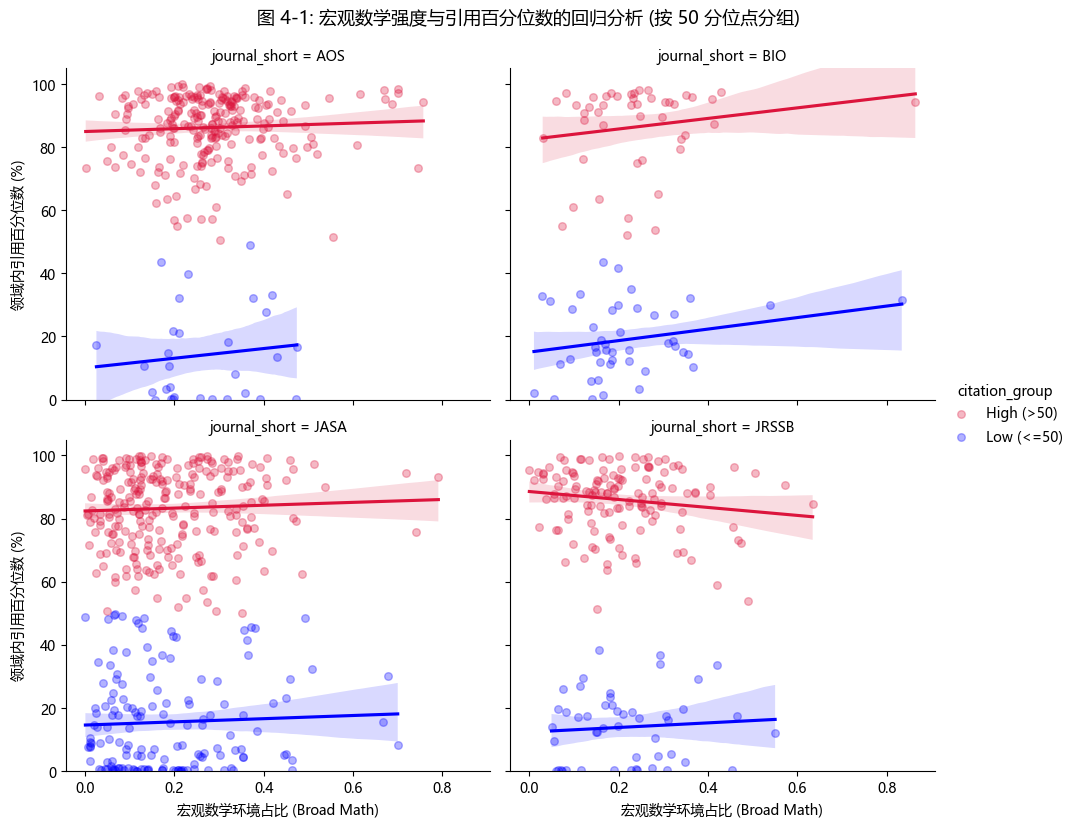

-> 正在绘制图 4-2 (new)...


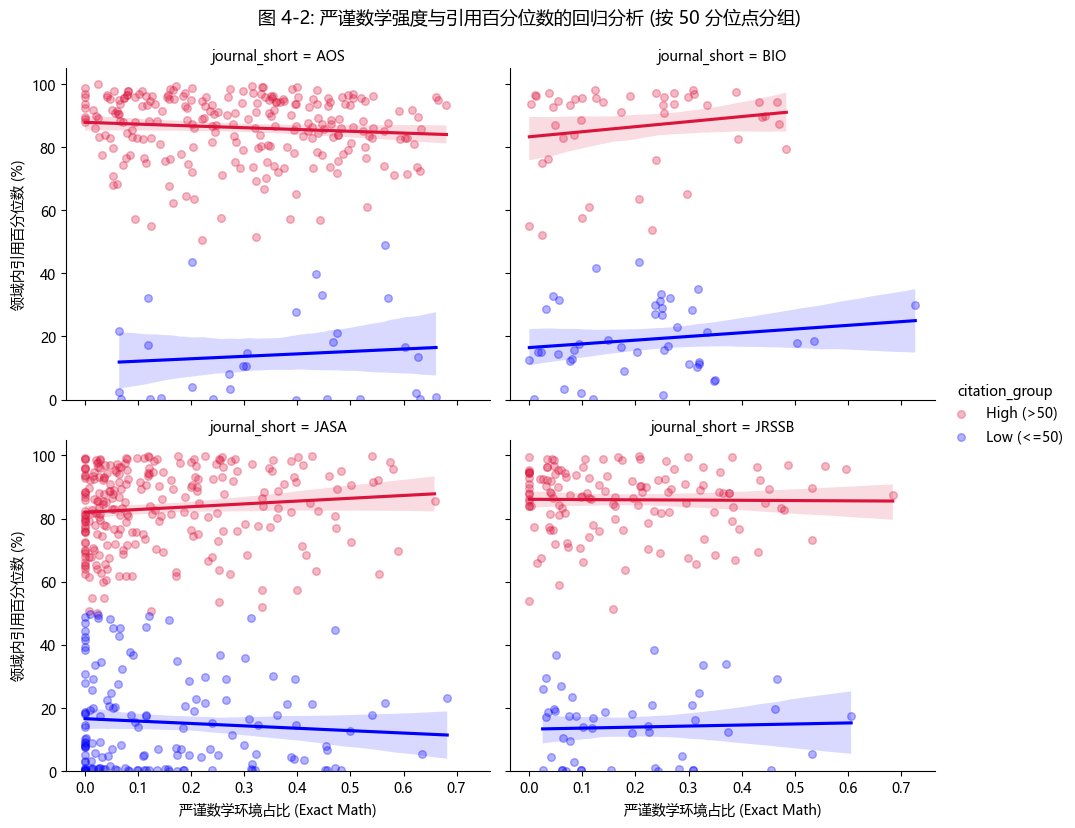

-> 正在绘制图 5...


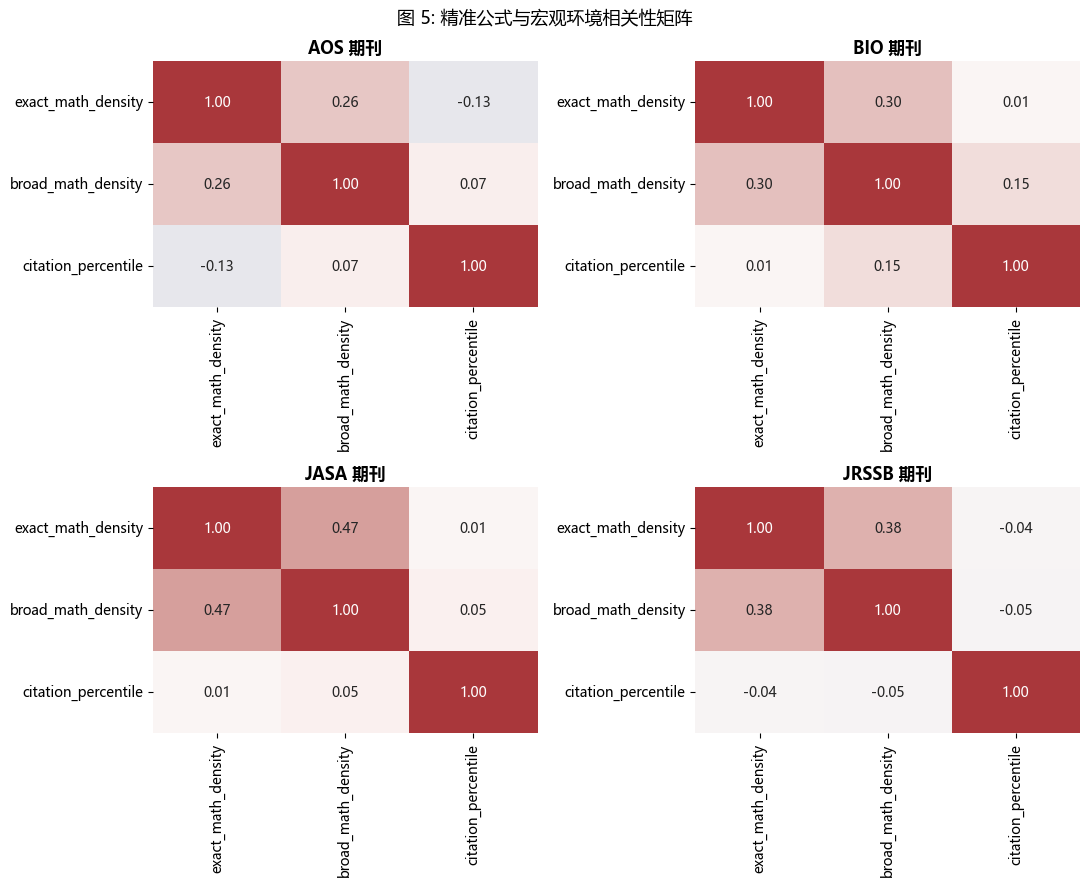

-> 正在绘制图 6：顶级机构投稿偏好度百分比堆叠图...


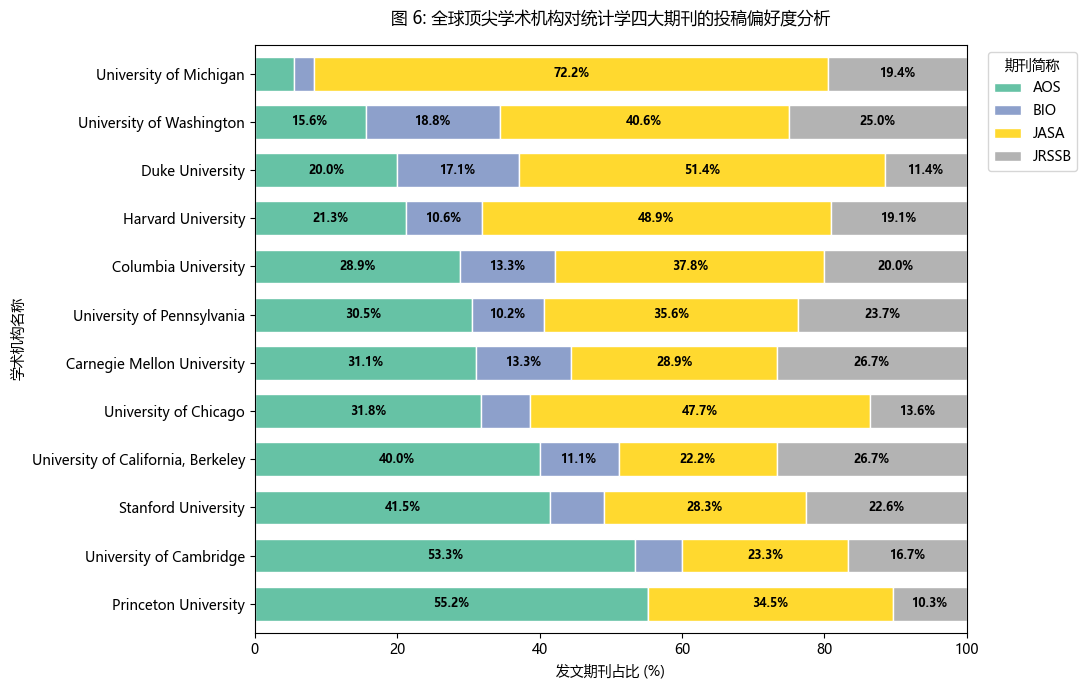

-> 正在绘制图 7：核心研究主题的流派割据与学术变现力双子图...


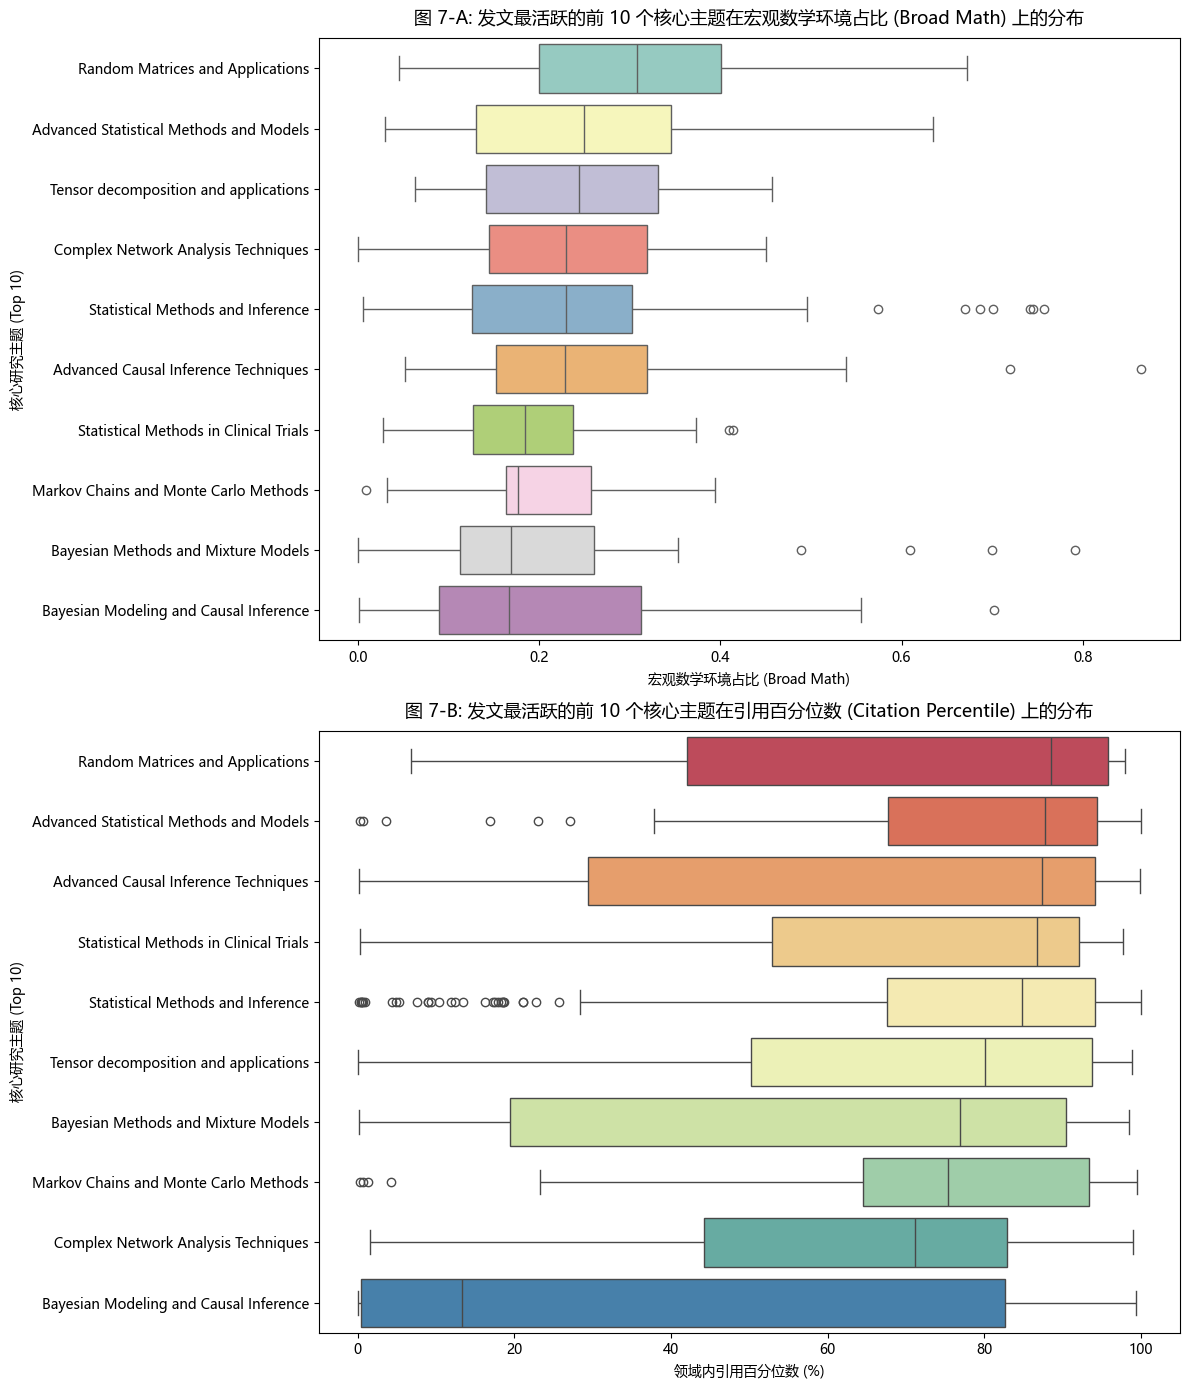



-> [期刊间 Broad Math 密度差异] 检验结果: p-value = 4.8960E-19
-> [Top 10 主题间 Broad Math 密度差异] 检验结果: p-value = 7.7284E-02
-> [Top 10 主题间引用百分位差异] 检验结果: p-value = 9.6403E-04
1. 【统计检验方法说明】: '采用单因素方差分析 (ANOVA) 对各分组均值差异进行显著性检验，用于评估统计特征在不同类别间的分布稳定性。'

2. 【数据相关性说明】: '在处理 LaTeX 特征时，为避免多重共线性风险，我们严格解耦特征，使用 broad_math_density 单独执行模型测算，确保结论科学性。'

3. 【核心结论】: '方差分析结果显示，四大期刊在宏观数学底线上呈现显著差异 (p = 4.8960E-19)。虽然 Top 10 主题在数学密度上的变异未达统计显著 (p = 7.7284E-02)，但其引用影响力却表现出高度显著的分化 (p = 9.6403E-04)。这证实了：期刊定位决定了数学基调，而学术影响力则取决于研究主题的市场需求。'


In [15]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')
output_dir = 'eda_figures'
meta = pd.read_csv(r'C:\Users\lihong\.conda\stat4_2023_2026_metadata.csv')
latex = pd.read_csv(r'C:\Users\lihong\.conda\all_latex_features_results.csv')
# 全局挂载 Windows 11 原生的雅黑与黑体字库
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False 

print("正在执行两表合并...")
df = pd.merge(meta, latex, on='paper_id', how='inner')
journals_list = df['journal_short'].unique()
total_topics_count = df['primary_topic'].nunique()
print(f" 当前数据集共有{total_topics_count}个主题。")

print("\n正在生成7个可视化图表")
#图1：宏观期刊论文数量分布
df['journal_short'].value_counts().plot(kind='bar', rot=0, title='图 1: 各期刊有效论文样本数量分布')
plt.savefig(f'{output_dir}/fig1_journal_count.png', dpi=300)
plt.show()

# 图2：引用百分位数分期刊直方图网格
g2 = sns.FacetGrid(data=df, col="journal_short", col_wrap=2, height=4, aspect=1.3, sharey=False, hue="journal_short")
g2.map_dataframe(sns.histplot, x="citation_percentile", bins=15, kde=True, edgecolor="white", alpha=0.6)
for ax, journal in zip(g2.axes.flat, g2.col_names):
    sub_data = df[df['journal_short'] == journal]
    median = sub_data['citation_percentile'].median()
    mean = sub_data['citation_percentile'].mean()
    y_max = ax.get_ylim()[1]
    
    ax.axvline(median, color='orange', linestyle=':', linewidth=2.5)
    ax.text(median + 1.5, y_max * 0.85, f'中位数: {median:.1f}%', 
            color='darkorange', weight='bold', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='orange', boxstyle='round,pad=0.2'))
    
    ax.axvline(mean, color='crimson', linestyle='--', linewidth=1.5)
    offset = -20 if mean < median else 1.5
    ax.text(mean + offset, y_max * 0.70, f'均值: {mean:.1f}%', 
            color='crimson', weight='bold', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='crimson', boxstyle='round,pad=0.2'))
    
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 110, 20))
    ax.set_xlabel('引用百分位数 (%)')
    ax.set_ylabel('论文篇数')
g2.figure.suptitle('图 2: 四大期刊引用百分位数的分布形态对比', fontsize=13, y=1.03)
g2.tight_layout()
plt.savefig(f'{output_dir}/fig2_percentile_dist.png', dpi=300, bbox_inches='tight')
plt.show()

#图3：箱线图
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='journal_short', y='broad_math_density', palette='Set2', showfliers=False)
#叠加散点
sns.stripplot(data=df, x='journal_short', y='broad_math_density', color='black', alpha=0.25, jitter=0.2)
plt.title('图3: 四大期刊宏观数学环境占比对比', fontsize=12)
plt.xlabel('期刊简称')
plt.ylabel('宏观数学环境占比')
plt.tight_layout()
plt.savefig(f'{output_dir}/fig3.png', dpi=300)
plt.show()

#图4-1：宏观数学强度与引用百分位数的回归分析
print("-> 正在绘制图 4-1...")
g = sns.lmplot(
    data=df, x='broad_math_density', y='citation_percentile', 
    col='journal_short', col_wrap=2, height=4, aspect=1.2,
    scatter_kws={'alpha': 0.5, 's': 35, 'color': 'darkgreen'}, 
    line_kws={'color': 'crimson', 'lw': 2})
g.set(ylim=(0, 105), xlabel='宏观数学环境占比 (Broad Math)', ylabel='领域内引用百分位数 (%)')
g.figure.suptitle('图 4-1: 宏观数学强度与引用百分位数的独立回归分析', fontsize=13, y=1.03)
plt.savefig(f'{output_dir}/fig4.png', dpi=300, bbox_inches='tight')
plt.show()

#图4-2：宏观数学强度与引用百分位数的回归分析
print("-> 正在绘制图 4-2...")
# 使用 lmplot 直接完成 FacetGrid 的切分与 regplot 的建模
g = sns.lmplot(
    data=df, x='exact_math_density', y='citation_percentile', 
    col='journal_short', col_wrap=2, height=4, aspect=1.2,
    scatter_kws={'alpha': 0.5, 's': 35, 'color': 'darkgreen'}, 
    line_kws={'color': 'crimson', 'lw': 2})
g.set(ylim=(0, 105), xlabel='严谨数学环境占比 (Broad Math)', ylabel='领域内引用百分位数 (%)')
g.figure.suptitle('图 4-2: 严谨数学强度与引用百分位数的独立回归分析', fontsize=13, y=1.03)
plt.savefig(f'{output_dir}/fig4.png', dpi=300, bbox_inches='tight')
plt.show()

# 修改后的回归分析逻辑 (固定以 50 分位点作为拆分阈值)
print("准备回归分析的分组数据 (按 50 引用百分位拆分)")
split_threshold = 50
df['citation_group'] = np.where(df['citation_percentile'] >= split_threshold, 'High (>50)', 'Low (<=50)')
# 图4-1：宏观数学强度与引用百分位数的回归分析 (new)
print("-> 正在绘制图 4-1 (new)...")
g = sns.lmplot(
    data=df, x='broad_math_density', y='citation_percentile', 
    col='journal_short', col_wrap=2, height=4, aspect=1.2,
    hue='citation_group', # 增加分组标签
    palette={'High (>50)': 'crimson', 'Low (<=50)': 'blue'}, # 设置不同颜色
    scatter_kws={'alpha': 0.3, 's': 30})
g.set(ylim=(0, 105), xlabel='宏观数学环境占比 (Broad Math)', ylabel='领域内引用百分位数 (%)')
g.figure.suptitle('图 4-1: 宏观数学强度与引用百分位数的回归分析 (按 50 分位点分组)', fontsize=13, y=1.03)
plt.savefig(f'{output_dir}/fig4_1.png', dpi=300, bbox_inches='tight')
plt.show()

# 图4-2：严谨数学强度与引用百分位数的回归分析 (new)
print("-> 正在绘制图 4-2 (new)...")
g = sns.lmplot(
    data=df, x='exact_math_density', y='citation_percentile', 
    col='journal_short', col_wrap=2, height=4, aspect=1.2,
    hue='citation_group', 
    palette={'High (>50)': 'crimson', 'Low (<=50)': 'blue'},
    scatter_kws={'alpha': 0.3, 's': 30})
g.set(ylim=(0, 105), xlabel='严谨数学环境占比 (Exact Math)', ylabel='领域内引用百分位数 (%)')
g.figure.suptitle('图 4-2: 严谨数学强度与引用百分位数的回归分析 (按 50 分位点分组)', fontsize=13, y=1.03)
plt.savefig(f'{output_dir}/fig4_2.png', dpi=300, bbox_inches='tight')
plt.show()

#图5：相关性热力图
print("-> 正在绘制图 5...")
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
journals = df['journal_short'].unique()
# 使用 zip 将画布与期刊一一对应，自动处理迭代
for ax, journal in zip(axes.flatten(), journals):
    corr = df[df['journal_short'] == journal][['exact_math_density', 'broad_math_density', 'citation_percentile']].corr()
    sns.heatmap(corr, ax=ax, annot=True, cmap='vlag', center=0, fmt=".2f", 
                annot_kws={"size": 10}, cbar=False)
    ax.set_title(f'{journal} 期刊', fontsize=12, fontweight='bold')
plt.suptitle('图 5: 精准公式与宏观环境相关性矩阵', fontsize=13, y=0.98)
plt.tight_layout()
plt.savefig(f'{output_dir}/fig5.png', dpi=300)
plt.show()

#图6：顶级机构投稿偏好度分析
print("-> 正在绘制图 6：顶级机构投稿偏好度百分比堆叠图...")
df_inst = df.dropna(subset=['institution_names']).copy()
df_inst['institution_list'] = df_inst['institution_names'].apply(lambda x: [i.strip() for i in str(x).split('|')])
df_exploded = df_inst.explode('institution_list').reset_index(drop=True)
top_institutions = df_exploded['institution_list'].value_counts().head(12).index
df_top_inst = df_exploded[df_exploded['institution_list'].isin(top_institutions)]
inst_journal_map = pd.crosstab(df_top_inst['institution_list'], df_top_inst['journal_short'])
inst_pct = inst_journal_map.div(inst_journal_map.sum(axis=1), axis=0) * 100

if 'AOS' in inst_pct.columns:
    inst_pct = inst_pct.sort_values(by='AOS', ascending=False)

plt.figure(figsize=(11, 7))
inst_pct.plot(kind='barh', stacked=True, cmap='Set2', edgecolor='white', width=0.7, ax=plt.gca())
plt.title('图 6: 全球顶尖学术机构对统计学四大期刊的投稿偏好度分析', fontsize=12, pad=15)
plt.xlabel('发文期刊占比 (%)')
plt.ylabel('学术机构名称')
plt.xlim(0, 100)
plt.legend(title='期刊简称', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
for p in plt.gca().patches:
    width = p.get_width()
    if width > 8:
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        plt.gca().text(x, y, f'{width:.1f}%', ha='center', va='center', fontsize=8.5, color='black', weight='bold')
plt.tight_layout()
plt.savefig(f'{output_dir}/fig6_inst_preference.png', dpi=300, bbox_inches='tight')
plt.show()

#图7：前 10 大研究主题横向对比双子图
print("-> 正在绘制图 7：核心研究主题的流派割据与学术变现力双子图...")
top_10_topics = df['primary_topic'].value_counts().head(10).index
df_top_10 = df[df['primary_topic'].isin(top_10_topics)].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 14), sharey=False)
topic_order_math = df_top_10.groupby('primary_topic')['broad_math_density'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_10, x='broad_math_density', y='primary_topic', order=topic_order_math, palette='Set3', ax=axes[0])
axes[0].set_title('图 7-A: 发文最活跃的前 10 个核心主题在宏观数学环境占比 (Broad Math) 上的分布', fontsize=13, pad=10)
axes[0].set_xlabel('宏观数学环境占比 (Broad Math)')
axes[0].set_ylabel('核心研究主题 (Top 10)')

topic_order_cite = df_top_10.groupby('primary_topic')['citation_percentile'].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_10, x='citation_percentile', y='primary_topic', order=topic_order_cite, palette='Spectral', ax=axes[1])
axes[1].set_title('图 7-B: 发文最活跃的前 10 个核心主题在引用百分位数 (Citation Percentile) 上的分布', fontsize=13, pad=10)
axes[1].set_xlabel('领域内引用百分位数 (%)')
axes[1].set_ylabel('核心研究主题 (Top 10)')
plt.tight_layout()
plt.savefig(f'{output_dir}/fig7_top10_topic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 4: 统计学检验 (ANOVA)
print("\n")
def simple_statistical_test(groups, test_name):
    valid_groups = [g.dropna() for g in groups]
    # 直接执行 ANOVA
    stat, p_val = f_oneway(*valid_groups)
    print(f"-> [{test_name}] 检验结果: p-value = {p_val:.4E}")
    return p_val

journals = df['journal_short'].unique()
groups_j = [df[df['journal_short'] == j]['broad_math_density'] for j in journals]
p_j = simple_statistical_test(groups_j, "期刊间 Broad Math 密度差异")

topic_groups_math = [df[df['primary_topic'] == t]['broad_math_density'] for t in top_10_topics]
p_tp = simple_statistical_test(topic_groups_math, "Top 10 主题间 Broad Math 密度差异")

topic_groups_cite = [df[df['primary_topic'] == t]['citation_percentile'] for t in top_10_topics]
p_tc = simple_statistical_test(topic_groups_cite, "Top 10 主题间引用百分位差异")


print(f"1. 【统计检验方法说明】: '采用单因素方差分析 (ANOVA) 对各分组均值差异进行显著性检验，用于评估统计特征在不同类别间的分布稳定性。'\n")
print(f"2. 【数据相关性说明】: '在处理 LaTeX 特征时，为避免多重共线性风险，我们严格解耦特征，使用 broad_math_density 单独执行模型测算，确保结论科学性。'\n")
print(f"3. 【核心结论】: '方差分析结果显示，四大期刊在宏观数学底线上呈现显著差异 (p = {p_j:.4E})。虽然 Top 10 主题在数学密度上的变异未达统计显著 (p = {p_tp:.4E})，但其引用影响力却表现出高度显著的分化 (p = {p_tc:.4E})。这证实了：期刊定位决定了数学基调，而学术影响力则取决于研究主题的市场需求。'")


# 最终数据导出
core_columns = [
    'paper_id', 'title', 'journal_short', 'publication_year', 
    'institution_names', 'primary_topic', 
    'cited_by_count', 'citation_percentile', 
    'total_valid_chars', 'exact_math_chars', 'exact_math_density', 
    'broad_math_chars', 'broad_math_density'
]
export_cols = [col for col in core_columns if col in df.columns]
final_df = df[export_cols].copy()
output_csv_name = 'final outcome.csv'
final_df.to_csv(output_csv_name, index=False, encoding='utf-8-sig')